In [64]:
from hnn_core.optimization import Optimizer, add_opt_drives, set_params_opt_drives
from hnn_core import jones_2009_model, simulate_dipole
from hnn_core.network_models import add_erp_drives_to_jones_model
from hnn_core.extracellular import calculate_csd2d, _get_laminar_z_coords

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

In [30]:
df_csd1 = pd.read_csv('../data/2-pb3738017_trace8_with_time.txt', delimiter=' ')
cs_csd1 = CubicSpline(df_csd1['time_ms'], df_csd1['csd_trace8'])

df_csd2 = pd.read_csv('../data/2-pb3738017_trace16_with_time.txt', delimiter=' ')
cs_csd2 = CubicSpline(df_csd2['time_ms'], df_csd2['csd_trace16'])

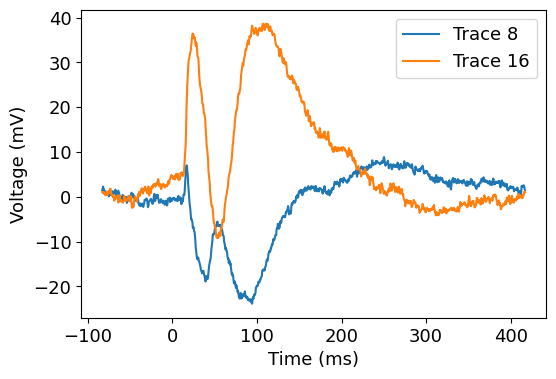

In [31]:
labelsize = 13
ticksize = 13
legendsize = 13

plt.figure(figsize=(6,4))
plt.plot(df_csd1['time_ms'], df_csd1['csd_trace8'], label='Trace 8')
plt.plot(df_csd2['time_ms'], df_csd2['csd_trace16'], label='Trace 16')
plt.xlabel('Time (ms)', fontsize=labelsize)
plt.ylabel('Voltage (mV)', fontsize=labelsize)
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.legend(fontsize=legendsize)

In [55]:
n_trials = 5
scaling_factor = 1000
window_length = 40
tstop = 500
# dt = 0.025
dt = 0.5

max_iter = 100
popsize = 16

net = jones_2009_model()
add_erp_drives_to_jones_model(net)

depths = np.arange(-325, 2150, 100)
electrode_pos = [(135, 135, dep) for dep in depths]
net.add_electrode_array('shank1', electrode_pos)

dpl = simulate_dipole(net, tstop=tstop, dt=dt, verbose=False)

In [69]:
times = dpl[0].times

contact_labels, delta = _get_laminar_z_coords(net.rec_arrays['shank1'].positions)
hnn_csd_data = calculate_csd2d(lfp_data=net.rec_arrays['shank1'].voltages[0], delta=delta)

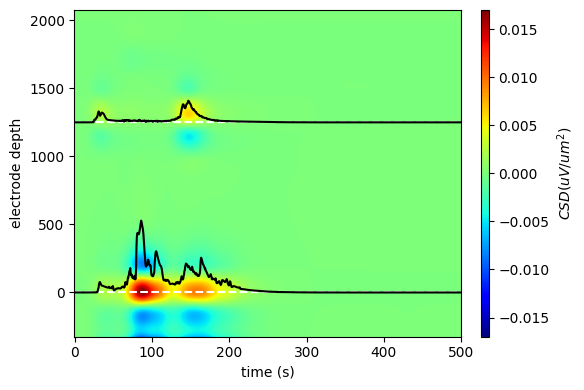

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(6,4),)

pos1, pos2 = 0, 1250
ax.axhline(pos1, color='white', linestyle='--')
ax.axhline(pos2, color='white', linestyle='--')

pos1_idx = np.argmin(np.abs(depths - pos1))
pos2_idx = np.argmin(np.abs(depths - pos2))

csd_scale = 2e4
plt.plot(times, csd_data[pos1_idx, :] * csd_scale + pos1, color='k')
plt.plot(times, csd_data[pos2_idx, :] * csd_scale + pos2, color='k')


_ = net.rec_arrays['shank1'][0].smooth(window_len=window_length).plot_csd(ax=ax)



In [ ]:
def csd_obj_fun():
    pass

In [ ]:
net_base = jones_2009_model()
constraints, initial_params = add_opt_drives(net_base, n_prox=2, n_dist=1)

optim = Optimizer(net_base, tstop=tstop, constraints=constraints, solver='cma',
                set_params=set_params_opt_drives, initial_params=initial_params, max_iter=max_iter, obj_fun=csd_obj_fun)
                

optim.fit(target=dipole_experimental, n_trials=n_trials, scale_factor=scaling_factor,
        smooth_window_len=window_length, dt=dt, popsize=popsize)